# Fetal Health Classification - Data Pipeline & Exploratory Analysis

This notebook documents the data preparation pipeline for the fetal health classification problem.

The workflow includes:
- Data loading
- Data cleaning
- Data validation (consistency tests)
- Train/test split (stratified)
- Statistical validation using Kolmogorov–Smirnov test

The goal is to ensure data quality, reproducibility, and proper preparation before model training.

## 1. Installing Required Libraries

In [18]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## 2. Defining All Hyperparameters and Data Paths in a Central Configuration Dictionary

In [3]:
config = {
    "data": {
        # Path to the raw fetal health dataset
        "raw_path": "data/raw/fetal_health.csv",

        # Proportion of data used for testing
        "test_size": 0.2,

        # Random seed for reproducibility in split
        "random_state": 42,

        # Target variable (classification label)
        # 1 = Normal, 2 = Suspect, 3 = Pathological
        "target_col": "fetal_health",

        # Threshold for dropping columns with too many missing values
        # Not used in this dataset (no missing values), but kept for generalization
        "missing_threshold": 0.5,

        # Strategy for imputing missing values (if needed)
        # Median is robust for numeric features
        "imputation_strategy": "median"
    },

    "model": {
        # MLP architecture (number of neurons per hidden layer)
        "hidden_sizes": [64, 32],

        # Dropout rate to reduce overfitting
        "dropout": 0.2,

        # Learning rate for optimizer
        "learning_rate": 0.001,

        # Batch size for training
        "batch_size": 32,

        # Number of training epochs
        "epochs": 100,

        # Early stopping patience (stop if no improvement)
        "early_stopping_patience": 10
    },

    # Global seed for full pipeline reproducibility
    "seed": 42
}

## 3. Defining Reproductibility Seed

In [4]:
import numpy as np
import torch
import random
import yaml

# Define a reproducibility seed

def set_seed(seed=42):
    """
    Sets a global seed to ensure reproducibility.
    """

    # Seed for Python's random number generator
    random.seed(seed)

    # Seed for NumPy operations
    np.random.seed(seed)

    # Seed for PyTorch
    torch.manual_seed(seed)
    
    # If a GPU is available, set the seed for CUDA as well
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

## 4. Loading Data

* Downloading data from KaggleHub:

In [5]:
import kagglehub
import shutil
import os


def download_data():
    """
    Downloads the dataset from Kaggle and saves it to data/raw.
    Handles kagglehub cache failures.
    """

    os.makedirs("data/raw", exist_ok=True)

    if os.path.exists("data/raw/fetal_health.csv"):
        print("Dataset already exists. Skipping download.")
        return

    print("Downloading dataset...")

    path = kagglehub.dataset_download("andrewmvd/fetal-health-classification")
    files = os.listdir(path)

    if not files:
        print("Empty cache detected. Clearing cache and retrying...")

        cache_dir = os.path.expanduser("~/.cache/kagglehub")
        if os.path.exists(cache_dir):
            shutil.rmtree(cache_dir)

        path = kagglehub.dataset_download("andrewmvd/fetal-health-classification")
        files = os.listdir(path)

        if not files:
            raise ValueError("Download failed even after clearing the cache.")

    for file in files:
        shutil.move(os.path.join(path, file), "data/raw/")

    print("Download completed successfully.")


## Applying function to download data
download_data()

Dataset already exists. Skipping download.


c:\Users\analu\Documents\Ana Luiza\Documentos - TAIAA\mlp_advanced_ai_topics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Loading data from CSV file:

In [6]:
import pandas as pd

def load_data(path):
    """
    Loads the dataset from CSV file.

    Args:
        path (str): Path to CSV file.

    Returns:
        pd.DataFrame: DataFrame with loaded data.
    """
    df = pd.read_csv(path)

    print(f"Dataset load from: {path}")
    print(f"Shape: {df.shape}")

    return df

## Applying loading data function
df = load_data(config["data"]["raw_path"])

Dataset load from: data/raw/fetal_health.csv
Shape: (2126, 22)


## 5. Exploratory Data Analysis (EDA)

### DataSet Preview

In [7]:
# Preview first rows
display(df.head())

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


### DataSet Structure

In [8]:
# Dataset structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability             

### Summary Statistics

In [9]:
# Summary statistics
display(df.describe())

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


### Feature Distributions (Histograms)

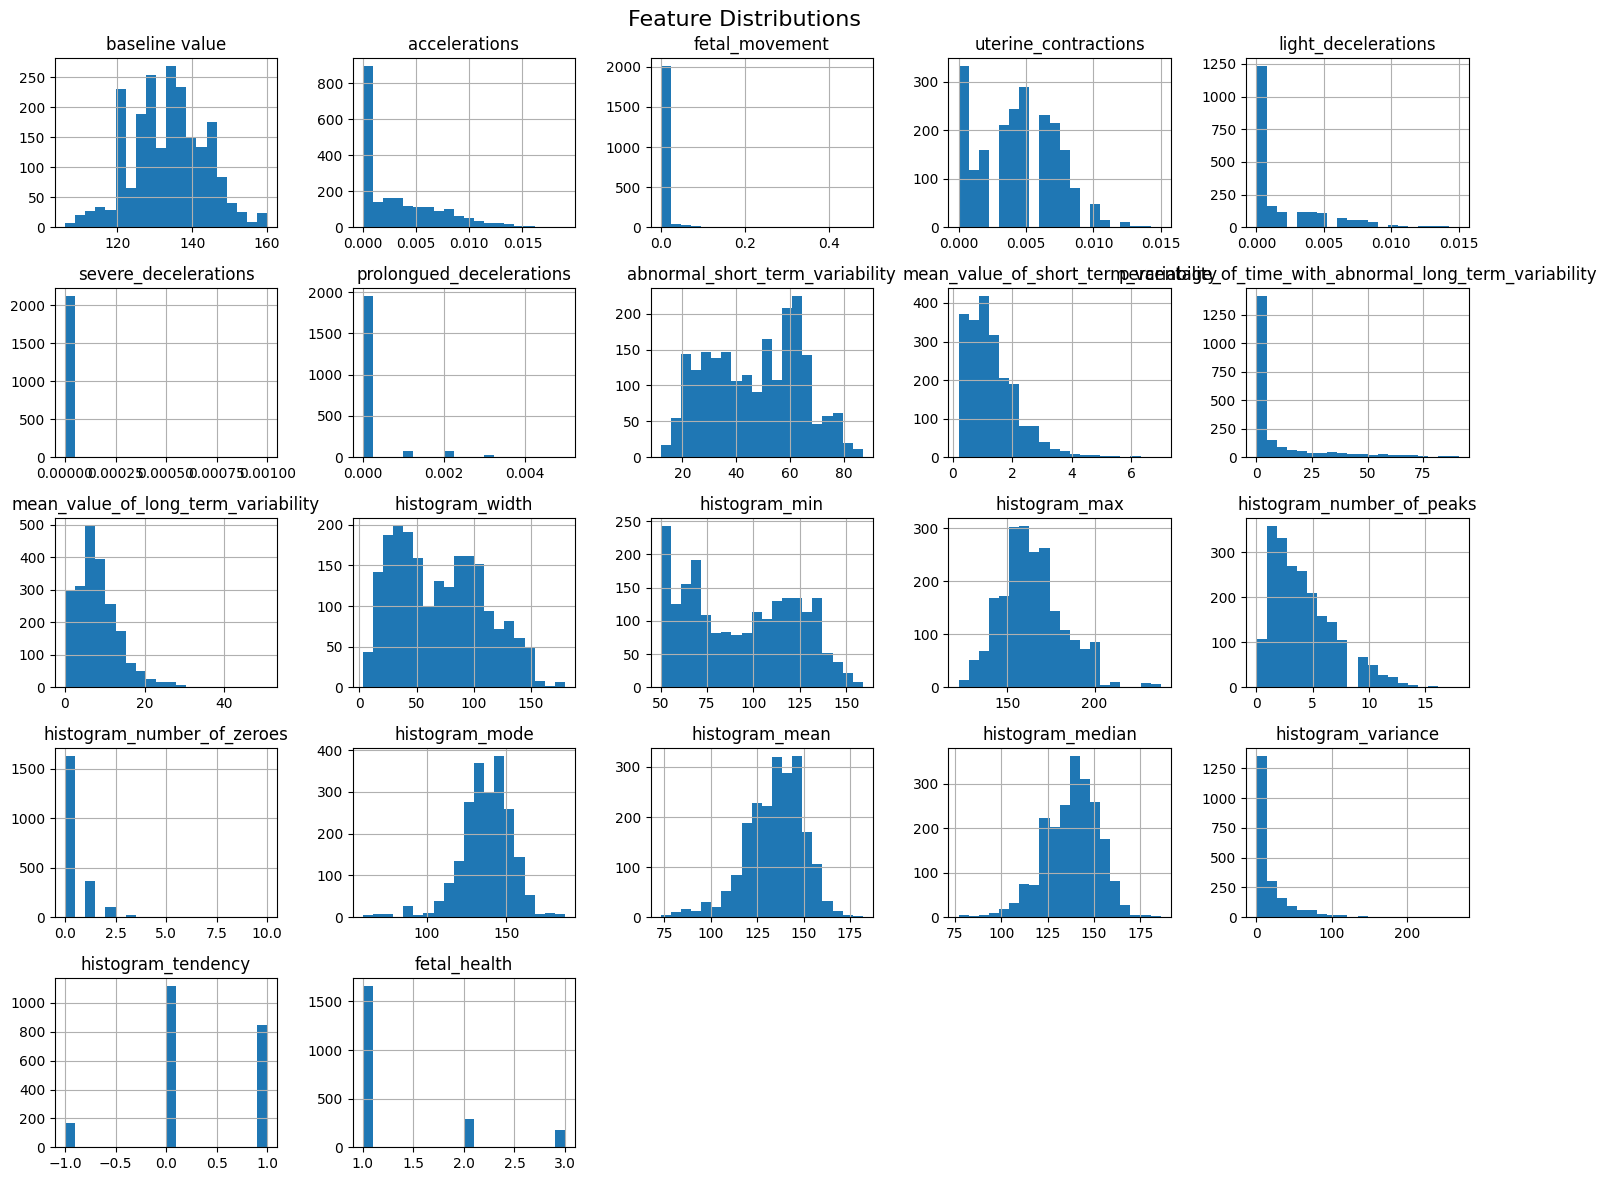

In [11]:
import matplotlib.pyplot as plt

# Visualize distribution of all numerical features
df.hist(figsize=(15, 12), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

### Outlier Detection (Boxplots)

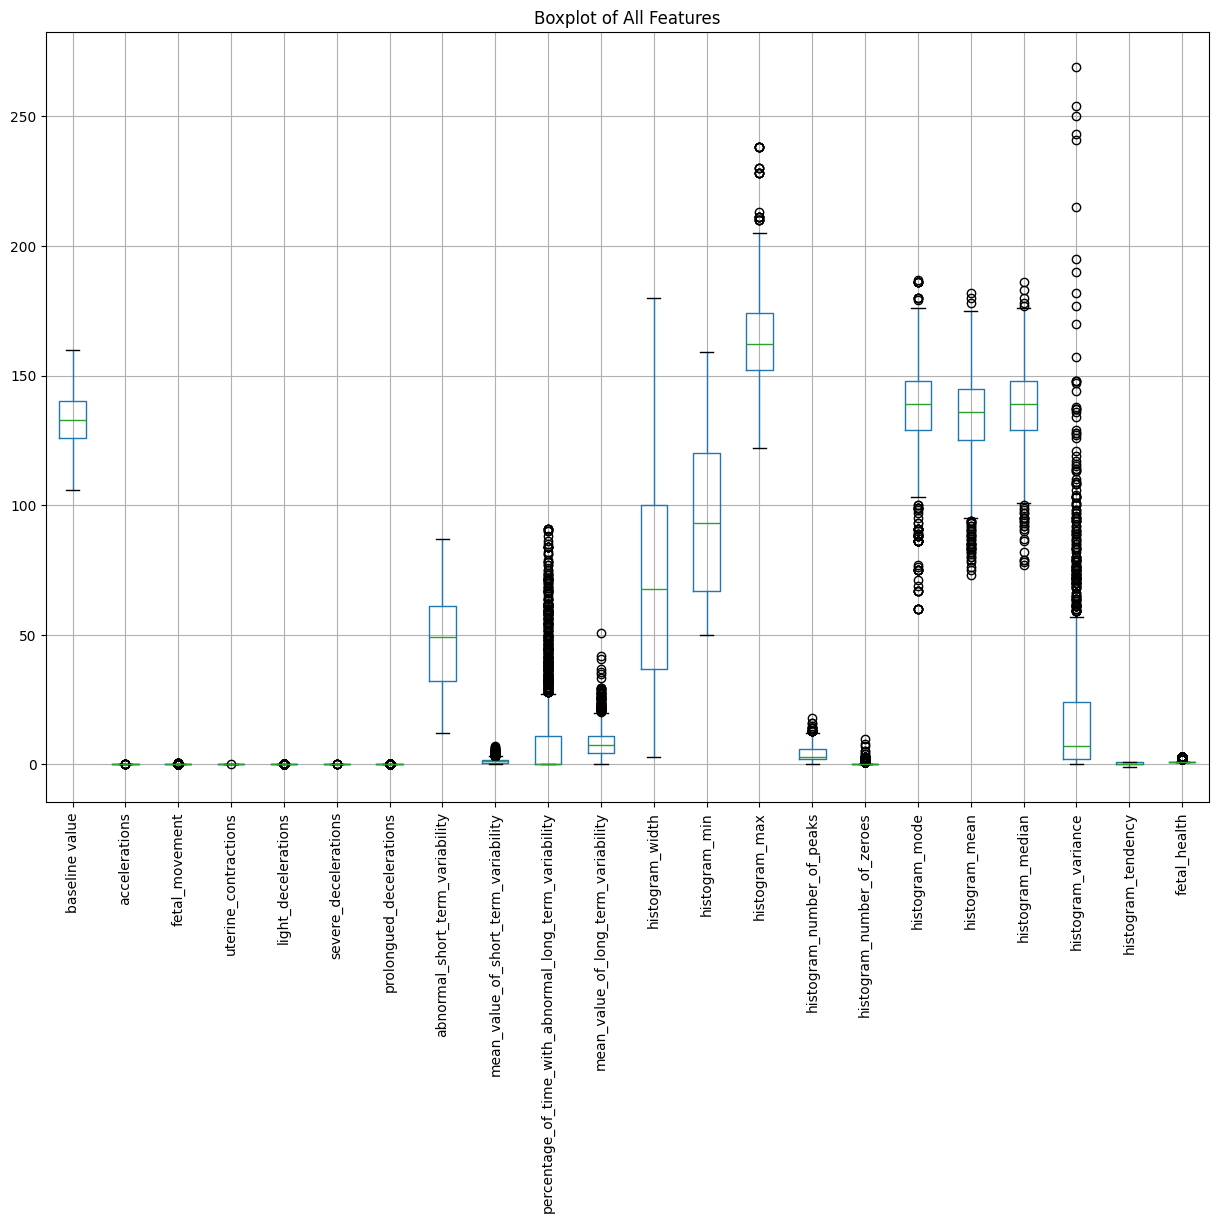

In [13]:
plt.figure(figsize=(15, 10))

df.boxplot(rot=90)

plt.title("Boxplot of All Features")
plt.show()

- Some mild outliers are present but not extreme

### Missing Values per Column

In [14]:
missing = df.isnull().sum()

print("\nMissing values per column:")
print(missing)

print("\nTotal missing values:", missing.sum())


Missing values per column:
baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mo

- No significant missing values were found

### Correlation Matrix

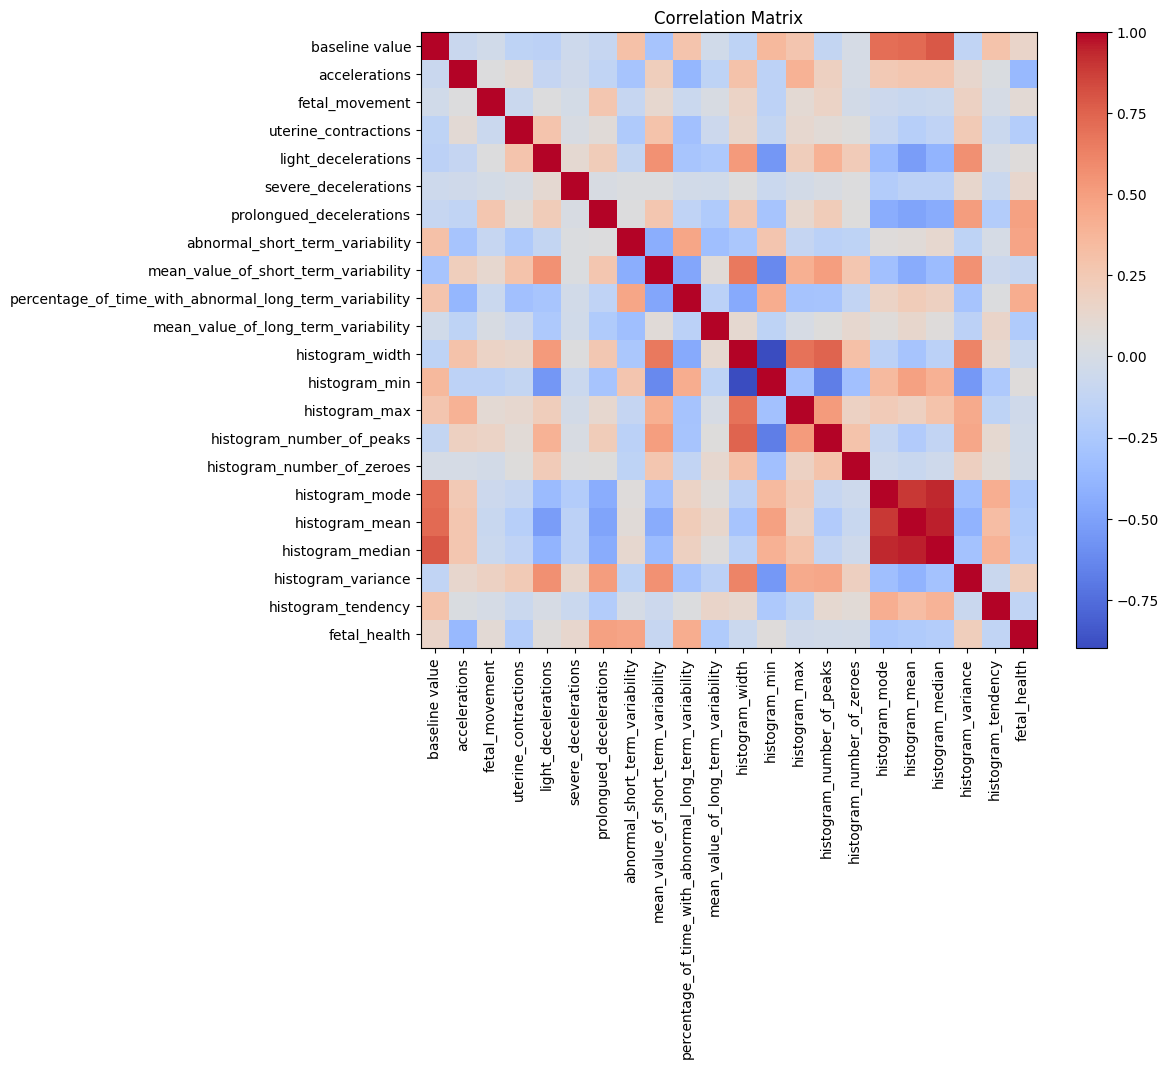

In [15]:
corr = df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

### Target Distribution

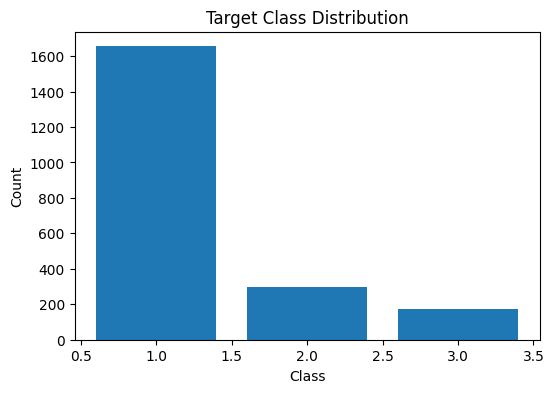

fetal_health
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64


In [16]:
target_col = config["data"]["target_col"]

counts = df[target_col].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

print(counts)

### Feature vs Target

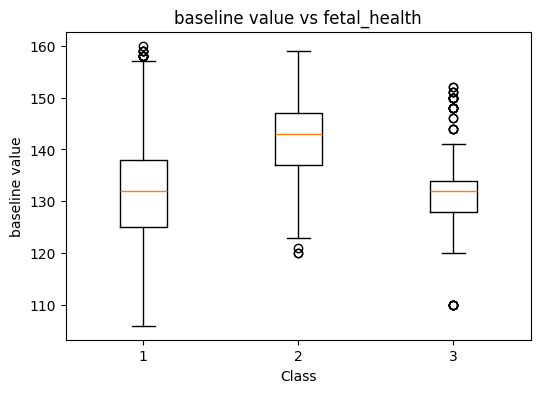

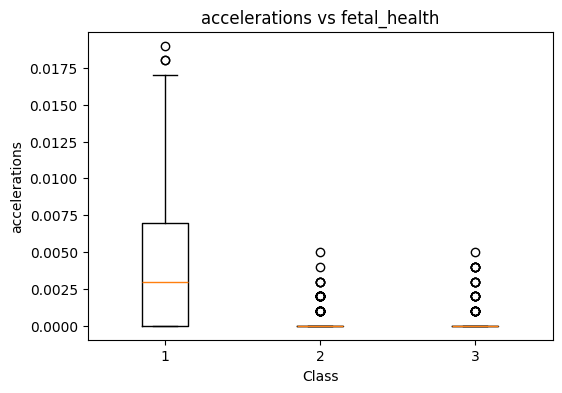

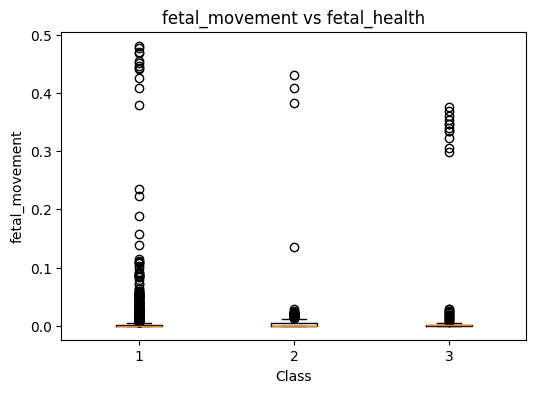

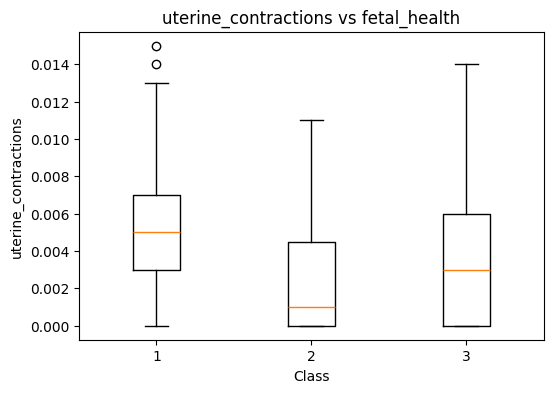

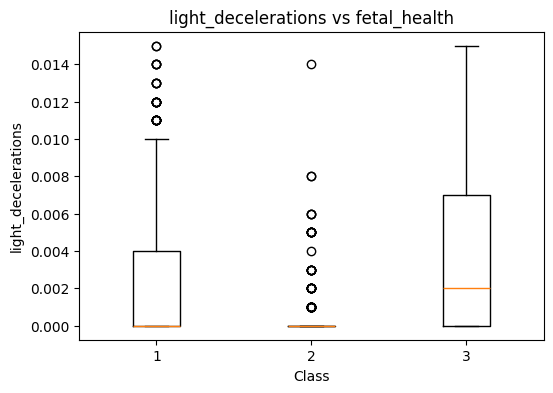

In [17]:
features = df.columns[:5]

for feature in features:
    if feature != target_col:
        plt.figure(figsize=(6, 4))

        data = [df[df[target_col] == cls][feature] for cls in sorted(df[target_col].unique())]

        plt.boxplot(data)
        plt.title(f"{feature} vs {target_col}")
        plt.xlabel("Class")
        plt.ylabel(feature)

        plt.show()

* Logging raw data as an W&B Artifact:

In [ ]:
import wandb
import os

# Log the raw dataset as an artifact for versioning
def log_raw_data(df):

    temp_path = "temp_raw.csv"
    df.to_csv(temp_path, index=False)

    artifact = wandb.Artifact(
        name="fetal_health_raw",
        type="dataset",
        description="Raw dataset"
    )

    artifact.add_file(temp_path)

    wandb.log_artifact(artifact)

    os.remove(temp_path)

# Initialize W&B run
run = wandb.init(
    project="mlp-fetal-health",
    name="fetal_health_raw",
    config=config
)

log_raw_data(df)

# Finish W&B run
wandb.finish()

## 6. Cleaning Data

* Removing duplicates:

In [42]:
def remove_duplicates(df):
    """
    Removes lines with duplicates on the dataset.
    """
    before = df.shape[0]

    df = df.drop_duplicates()

    after = df.shape[0]

    print(f"Removed duplicates: {before - after}")

    return df

* Checking for missing values:

In [43]:
def check_missing_values(df):
    """
    Checks for missing values on the dataset.
    """
    missing = df.isnull().sum()

    print("\nNull numbers per column:")
    print(missing)

    total_missing = missing.sum()

    print(f"\nTotal null numbers: {total_missing}")

    return total_missing

### Testing Cleaning Data

* Testing duplicates function:

In [44]:
import pandas as pd

def test_remove_duplicates():
    """
    Test if remove_duplicates correctly removes duplicate rows.
    """
    df = pd.DataFrame({
        "A": [1, 1, 2],
        "B": [3, 3, 4]
    })

    df_clean = remove_duplicates(df)

    # Should remove 1 duplicate
    assert len(df_clean) == 2
    assert df_clean.duplicated().sum() == 0

* Testing if the removing duplicates function does not modify de DataFrame:

In [45]:
def test_remove_duplicates_no_change():
    """
    Test if the function does not modify the DataFrame when there are no duplicates.
    """
    df = pd.DataFrame({
        "A": [1, 2, 3],
        "B": [4, 5, 6]
    })

    df_clean = remove_duplicates(df)

    assert len(df_clean) == 3

* Testing function for checking missing values:

In [46]:
def test_check_missing_values():
    """
    Test if the function correctly detects missing values.
    """
    df = pd.DataFrame({
        "A": [1, None, 2],
        "B": [3, 4, None]
    })

    missing = check_missing_values(df)

    # Total missing values = 2
    total_missing = missing.sum()

    assert total_missing == 2

### Cleaning the Data After Testing

In [47]:
# Remove duplicate rows
df = remove_duplicates(df)

Removed duplicates: 13


In [48]:
# Check for missing values
check_missing_values(df)


Null numbers per column:
baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode

np.int64(0)

## 7. Data Validation (Data Testing)

* Testing for missing values:

In [49]:
import pandas as pd

def validate_no_missing_values(df: pd.DataFrame) -> None:
    """
    Ensure that the dataset contains no missing values.
    """
    total_missing = df.isnull().sum().sum()
    assert total_missing == 0, \
        f"VALIDATION FAILED: {total_missing} missing values remain."
    print("PASS: no missing values.")

# Ensure no missing values remain
validate_no_missing_values(df)

PASS: no missing values.


* Testing target values:

In [50]:
import pandas as pd

def validate_target_values(
    df: pd.DataFrame,
    target_col: str,
    allowed_values
) -> None:
    """
    Ensure that the target column contains only valid values.
    """
    invalid_mask = ~df[target_col].isin(allowed_values)
    invalid_count = invalid_mask.sum()

    assert invalid_count == 0, \
        f"VALIDATION FAILED: {invalid_count} unexpected values in '{target_col}': " \
        f"{df.loc[invalid_mask, target_col].unique()}"

    print(f"PASS: '{target_col}' contains only valid values.")

# Validate target values
validate_target_values(
    df,
    config["data"]["target_col"],
    [1, 2, 3]  # fetal_health classes
)

PASS: 'fetal_health' contains only valid values.


* Testing for duplicates:

In [51]:
import pandas as pd

def validate_no_duplicates(df: pd.DataFrame) -> None:
    """
    Ensure that the dataset contains no duplicate rows.
    """
    total_duplicates = df.duplicated().sum()
    assert total_duplicates == 0, \
        f"VALIDATION FAILED: {total_duplicates} duplicate rows found."
    print("PASS: no duplicates.")

# Ensure no duplicate rows remain
validate_no_duplicates(df)

PASS: no duplicates.


## 8. Saving and Logging Clean Data

### Saving Clean Data:

In [ ]:
def save_clean_data(df):
    """
    Saves the clean dataset.
    """
    import os

    os.makedirs("data/processed", exist_ok=True)

    path = "data/processed/fetal_health_clean.csv"
    df.to_csv(path, index=False)

    print(f"Cleaned dataset saved at: {path}")

    return path

clean_path = save_clean_data(df)

Dataset limpo salvo em: data/processed/fetal_health_clean.csv


### Logging Clean Data on W&B

In [23]:
import wandb

def log_clean_data(path):
    """
    Logs the clean data as an Artifact.
    """

    artifact = wandb.Artifact(
        name="fetal_health_clean",
        type="dataset",
        description="Cleaned dataset after preprocessing"
    )

    artifact.add_file(path)

    wandb.log_artifact(artifact)

# Initialize W&B run
run = wandb.init(
    project="mlp-fetal-health",
    name="fetal_health_clean",
    config=config
)

log_clean_data(clean_path)

# Finish W&B run
wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\analu\_netrc.
wandb: Currently logged in as: iluizacosta (iluizacosta-ufrn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 9. Stratified Train/Test Split

* Splitting data:

In [ ]:
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.model_selection import train_test_split


def stratified_split(df: pd.DataFrame, target_col: str, test_size=0.2, random_state=42):
    """
    Performs stratified split training and testing.
    """

    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    train_df = pd.concat([X_train, y_train], axis=1)
    test_df = pd.concat([X_test, y_test], axis=1)

    return train_df, test_df

# Perform stratified split to preserve class distribution
train_df, test_df = stratified_split(
    df,
    config["data"]["target_col"]
)

* Kolmogorov–Smirnov (KS) Test

In [52]:
import wandb

def ks_test(train_df: pd.DataFrame, test_df: pd.DataFrame, columns: list) -> dict:
    """
    Compares distributions using KS Test only (Kolmogorov-Smirnov).
    """

    results = {}

    for col in columns:
        train_vals = train_df[col].dropna()
        test_vals = test_df[col].dropna()

        stat, p = ks_2samp(train_vals, test_vals)

        results[col] = {
            "test": "KS",
            "statistic": stat,
            "p_value": p
        }

    return results

# Compare feature distributions between train and test sets
feature_cols = [
    c for c in train_df.columns
    if c != config["data"]["target_col"]
]

ks_results = ks_test(train_df, test_df, feature_cols)

# Convert results to DataFrame
comp_df = pd.DataFrame(ks_results).T.reset_index()
comp_df.columns = ["feature", "test", "statistic", "p_value"]

print("\nKS Test Results:")
print(comp_df)


KS Test Results:
                                              feature test statistic   p_value
0                                      baseline value   KS  0.040612  0.613666
1                                       accelerations   KS  0.018252  0.999754
2                                      fetal_movement   KS  0.056384   0.22251
3                                uterine_contractions   KS  0.027693  0.949498
4                                 light_decelerations   KS  0.051275   0.32225
5                                severe_decelerations   KS  0.004142       1.0
6                            prolongued_decelerations   KS  0.016652  0.999965
7                     abnormal_short_term_variability   KS  0.059011  0.180508
8                mean_value_of_short_term_variability   KS  0.031003  0.888815
9   percentage_of_time_with_abnormal_long_term_var...   KS  0.044591  0.495311
10                mean_value_of_long_term_variability   KS  0.031526  0.877139
11                                

* Logging as a W&B Table

In [53]:
# Initialize W&B run
run = wandb.init(
    project="mlp-fetal-health",
    name="data_split",
    config=config
)

# Log KS test results as table
comp_table = wandb.Table(dataframe=comp_df)
wandb.log({"distribution_comparison": comp_table})

# Log dataset sizes
wandb.summary.update({
    "train_size": len(train_df),
    "test_size": len(test_df)
})

# Log average p-value
wandb.summary["avg_p_value"] = comp_df["p_value"].mean()

# Finish run
wandb.finish()

avg_p_value,0.55426
test_size,423
train_size,1690


### Saving Train/Split Data and Logging to W&B

* Saving Train/Split Data

In [30]:
train_path = "data/processed/train.csv"
test_path = "data/processed/test.csv"

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

* Logging to W&B

In [54]:
# Initialize W&B run
run = wandb.init(
    project="mlp-fetal-health",
    name="data_split_FINAL_TEST",
    config=config
)

# LOG SPLIT ARTIFACT TO W&B
artifact = wandb.Artifact(
    name="fetal_health_split",
    type="dataset",
    description="Train/test split",
)

# Add files
artifact.add_file(train_path)
artifact.add_file(test_path)

wandb.log_artifact(artifact)

# Log dataset sizes
wandb.summary.update({
    "train_size": len(train_df),
    "test_size": len(test_df)
})

# Finish W&B run
wandb.finish()

test_size,423
train_size,1690
